# HSSFLDON - Results Display Notebook

This notebook will be used to display the results of the model.

### Module Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import tabulate
import matplotlib.pyplot as plt

### Load Results

Load results from our json file. Results are saved in a dict like:

`{ trainingIteration: { passive_or_active: { loss: val, accuracy: val } } }`

In [2]:
def loadResults(resultsPath: str) -> dict:
    if not os.path.exists(resultsPath):
        print(f"Results file not found at path: {resultsPath}")
        raise FileNotFoundError(f"Results file not found at path: {resultsPath}")
    else:
        return json.load(open(resultsPath, "r"))

### Graph Accuracy

We will graph the accuracy for all training iterations for both passive and active learning, using different colors to differentiate the two evaluations for each iteration.

In [3]:
def plotAccuracies(results: dict):
    # Extract all accuracies
    accuracyDf = pd.DataFrame(columns=["iteration", "learning_mode", "accuracy"])
    for iteration in results:
        for learningMode in ["passive", "active"]:
            accuracy = results[iteration][learningMode].get("accuracy", None)
            if accuracy is not None:
                accuracyDf = pd.concat([accuracyDf, pd.DataFrame({"iteration": [iteration], "learning_mode": [learningMode], "accuracy": [accuracy]})], ignore_index=True)

    # Make figure for plotting
    plt.figure(figsize=(10, 6))

    # Plot passive learning accuracies as blue dots
    passiveDf = accuracyDf[accuracyDf["learning_mode"] == "passive"]
    plt.scatter(passiveDf["iteration"], passiveDf["accuracy"], color="blue", label="Passive Learning")

    # Plot active learning accuracies as orange dots
    activeDf = accuracyDf[accuracyDf["learning_mode"] == "active"]
    plt.scatter(activeDf["iteration"], activeDf["accuracy"], color="orange", label="Active Learning")

    # Best fit line
    zAccuracy = np.polyfit(accuracyDf["iteration"].astype(float), accuracyDf["accuracy"].astype(float), 1)
    pAccuracy = np.poly1d(zAccuracy)
    plt.plot(accuracyDf["iteration"].astype(float), pAccuracy(accuracyDf["iteration"].astype(float)), color="red", linestyle="--", label="Best Fit Line")

    # Add labels and title
    plt.xlabel("Iteration")
    plt.ylabel("Accuracy")
    plt.title("Learning Accuracy Over Iterations")
    plt.legend()
    plt.show()

## Graph Loss

Now do the same for loss!

In [4]:
def plotLosses(results: dict):
    # Extract all losses
    lossDf = pd.DataFrame(columns=["iteration", "learning_mode", "loss"])
    for iteration in results:
        for learningMode in ["passive", "active"]:
            loss = results[iteration][learningMode].get("loss", None)
            if loss is not None:
                lossDf = pd.concat([lossDf, pd.DataFrame({"iteration": [iteration], "learning_mode": [learningMode], "loss": [loss]})], ignore_index=True)

    # Make figure for plotting
    plt.figure(figsize=(10, 6))

    # Plot passive learning losses as blue dots
    passiveDf = lossDf[lossDf["learning_mode"] == "passive"]
    plt.scatter(passiveDf["iteration"], passiveDf["loss"], color="blue", label="Passive Learning")

    # Plot active learning losses as orange dots
    activeDf = lossDf[lossDf["learning_mode"] == "active"]
    plt.scatter(activeDf["iteration"], activeDf["loss"], color="orange", label="Active Learning")

    # Best fit line
    zLoss = np.polyfit(lossDf["iteration"].astype(float), lossDf["loss"].astype(float), 1)
    pLoss = np.poly1d(zLoss)
    plt.plot(lossDf["iteration"].astype(float), pLoss(lossDf["iteration"].astype(float)), color="red", linestyle="--", label="Best Fit Line")

    # Add labels and title
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Learning Loss Over Iterations")
    plt.legend()
    plt.show()

## Build Table

This will build a table to showcase the loss and accuracy over iterations.

In [5]:
def buildTable(results: dict) -> str:
    tableData = []
    for iteration in results:
        passiveAccuracy = results[iteration]["passive"].get("accuracy", "N/A")
        passiveLoss = results[iteration]["passive"].get("loss", "N/A")
        activeAccuracy = results[iteration]["active"].get("accuracy", "N/A")
        activeLoss = results[iteration]["active"].get("loss", "N/A")
        tableData.append([iteration, passiveAccuracy, activeAccuracy, passiveLoss, activeLoss])
    return tabulate.tabulate(tableData, headers=["Iteration", "Passive Accuracy", "Active Accuracy", "Passive Loss", "Active Loss"], tablefmt="grid")

## Version 1 - Single Max Confidence

Here we show the results for the initial try which used single max confidence.

In [6]:
v1ResultsPath = "singlemaxconfidence_results.json"
v1Results = loadResults(v1ResultsPath)
print(buildTable(v1Results))

+-------------+--------------------+-------------------+----------------+---------------+
|   Iteration |   Passive Accuracy |   Active Accuracy |   Passive Loss |   Active Loss |
+=============+====================+===================+================+===============+
|           1 |           0.765241 |          0.729406 |       0.507572 |      0.553964 |
+-------------+--------------------+-------------------+----------------+---------------+
|           2 |           0.765241 |          0.717415 |       0.512716 |      0.546591 |
+-------------+--------------------+-------------------+----------------+---------------+
|           3 |           0.765241 |          0.717415 |       0.515895 |      0.592445 |
+-------------+--------------------+-------------------+----------------+---------------+
|           4 |           0.765241 |          0.75325  |       0.511131 |      0.587892 |
+-------------+--------------------+-------------------+----------------+---------------+
|         

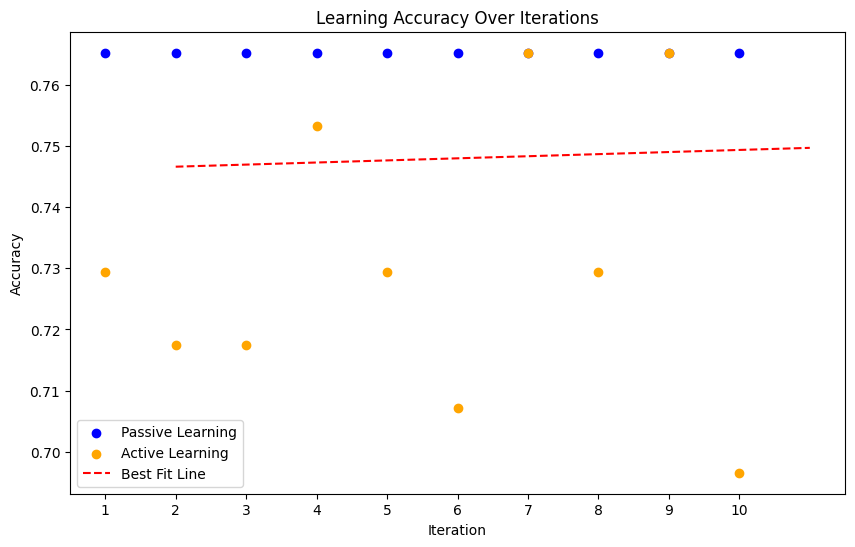

In [7]:
plotAccuracies(v1Results)

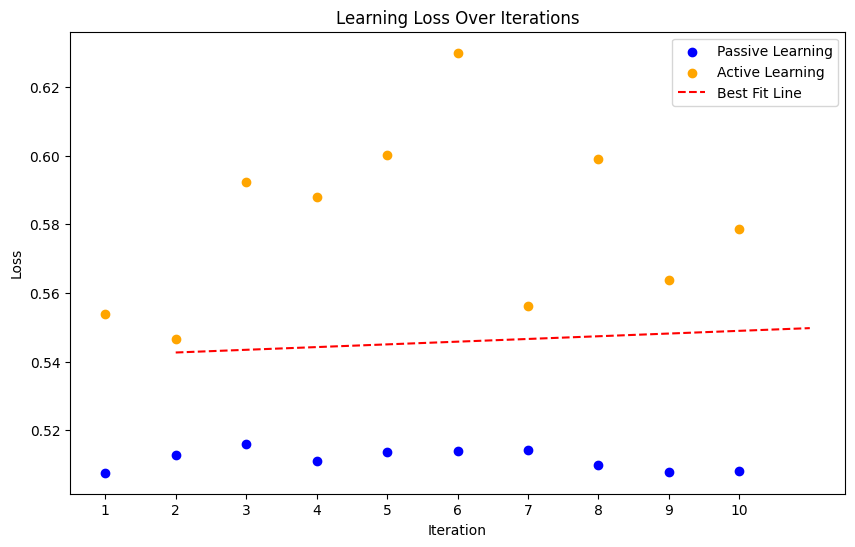

In [8]:
plotLosses(v1Results)

## Version 2 - Average Deviance Confidence

Here we show the results for the second try which used avg deviance instead of a single max certainty.

In [9]:
v2ResultsPath = "avgdevianceconfidence_results.json"
v2Results = loadResults(v2ResultsPath)
print(buildTable(v2Results))

+-------------+--------------------+-------------------+----------------+---------------+
|   Iteration |   Passive Accuracy |   Active Accuracy |   Passive Loss |   Active Loss |
+=============+====================+===================+================+===============+
|           1 |           0.765241 |          0.674052 |       0.503732 |      0.597273 |
+-------------+--------------------+-------------------+----------------+---------------+
|           2 |           0.765241 |          0.646462 |       0.503063 |      0.600078 |
+-------------+--------------------+-------------------+----------------+---------------+
|           3 |           0.765241 |          0.756705 |       0.507117 |      0.540727 |
+-------------+--------------------+-------------------+----------------+---------------+
|           4 |           0.765729 |          0.721911 |       0.495159 |      0.551964 |
+-------------+--------------------+-------------------+----------------+---------------+
|         

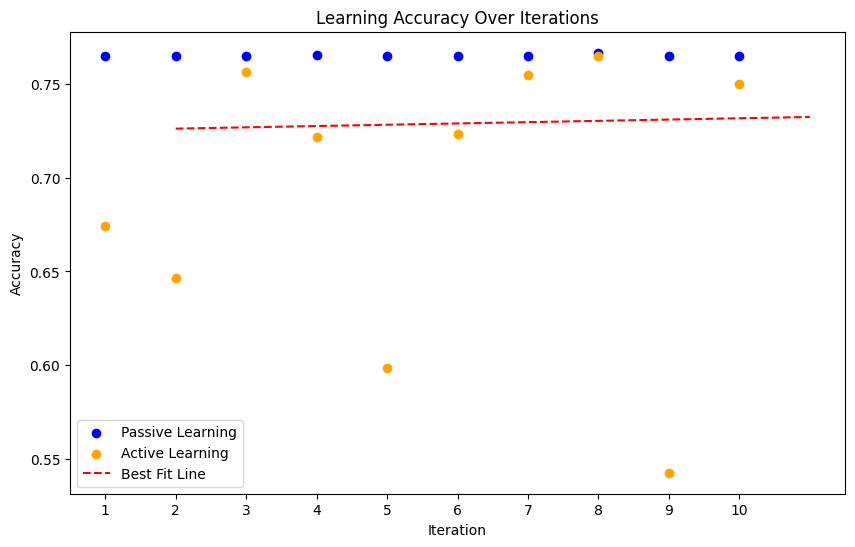

In [10]:
plotAccuracies(v2Results)

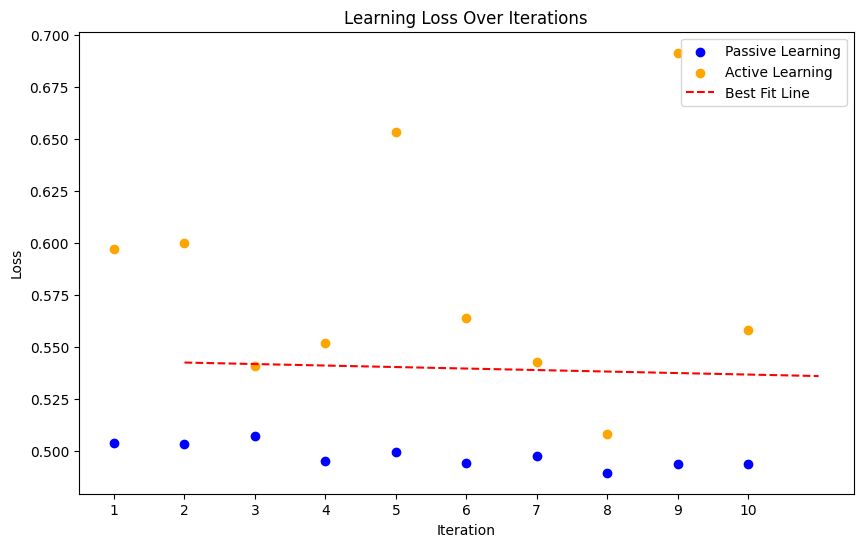

In [11]:
plotLosses(v2Results)

## Version 3 - Better Oracle Splitting

Here we show the results for the third version of the codebase. This update focuses mainly on the data pipeline, where we now have a better algorithm for splitting / biasing the dataset among clients. We also limit the number of samples for each client to 1000 and tune some hyperparameters.

In [12]:
v3ResultsPath = "neworaclesplit_results.json"
v3Results = loadResults(v3ResultsPath)
print(buildTable(v3Results))

+-------------+--------------------+-------------------+----------------+---------------+
|   Iteration |   Passive Accuracy |   Active Accuracy |   Passive Loss |   Active Loss |
+=============+====================+===================+================+===============+
|           1 |           0.709977 |          0.709944 |       0.574634 |      0.57281  |
+-------------+--------------------+-------------------+----------------+---------------+
|           2 |           0.692567 |          0.714182 |       0.575924 |      0.57658  |
+-------------+--------------------+-------------------+----------------+---------------+
|           3 |           0.66604  |          0.714182 |       0.56767  |      0.580475 |
+-------------+--------------------+-------------------+----------------+---------------+
|           4 |           0.666027 |          0.678838 |       0.601774 |      0.661316 |
+-------------+--------------------+-------------------+----------------+---------------+
|         

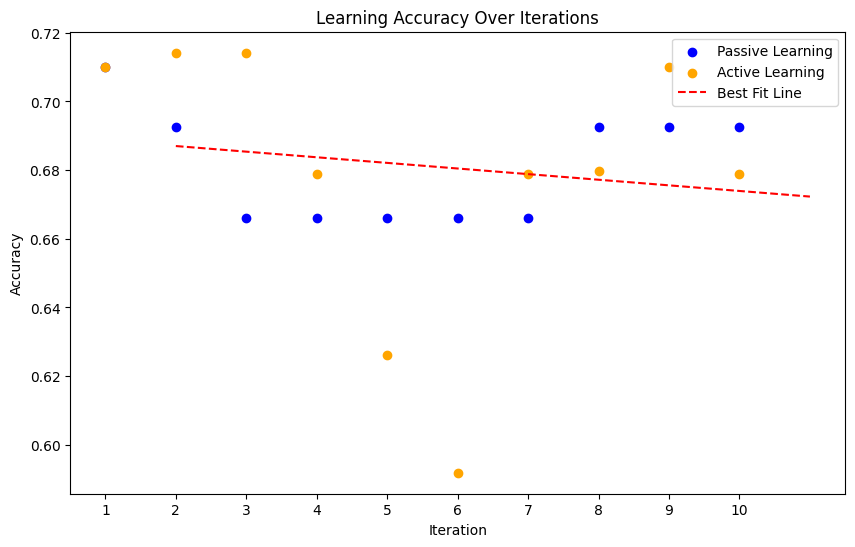

In [13]:
plotAccuracies(v3Results)

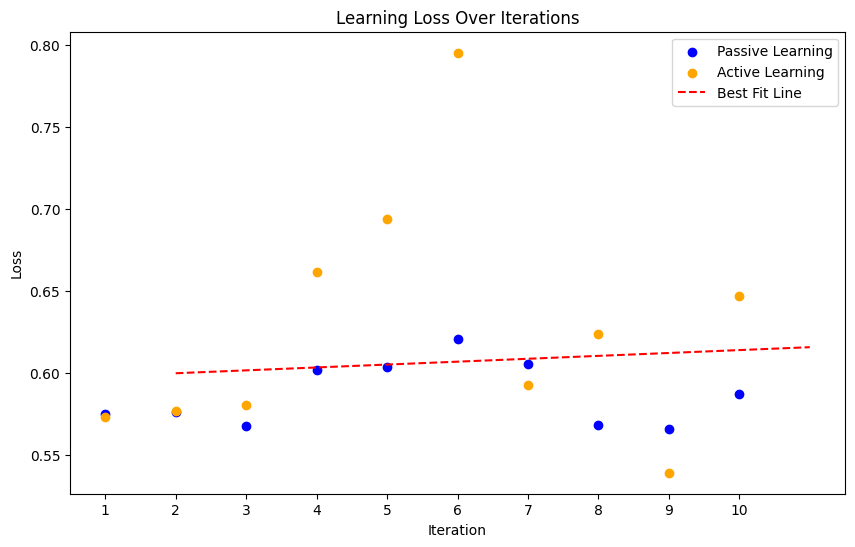

In [14]:
plotLosses(v3Results)

## Version 4 - Normalization Layer

The fourth version introduces a normalization layer to our classification head.

In [15]:
v4ResultsPath = "v4_normlayer_results.json"
v4Results = loadResults(v4ResultsPath)
print(buildTable(v4Results))

+-------------+--------------------+-------------------+----------------+---------------+
|   Iteration |   Passive Accuracy |   Active Accuracy |   Passive Loss |   Active Loss |
+=============+====================+===================+================+===============+
|           1 |           0.714182 |          0.669249 |       0.544137 |      0.584641 |
+-------------+--------------------+-------------------+----------------+---------------+
|           2 |           0.696797 |          0.696772 |       0.585664 |      0.564901 |
+-------------+--------------------+-------------------+----------------+---------------+
|           3 |           0.709977 |          0.561064 |       0.561391 |      0.639179 |
+-------------+--------------------+-------------------+----------------+---------------+
|           4 |           0.714182 |          0.598079 |       0.562305 |      0.624692 |
+-------------+--------------------+-------------------+----------------+---------------+
|         

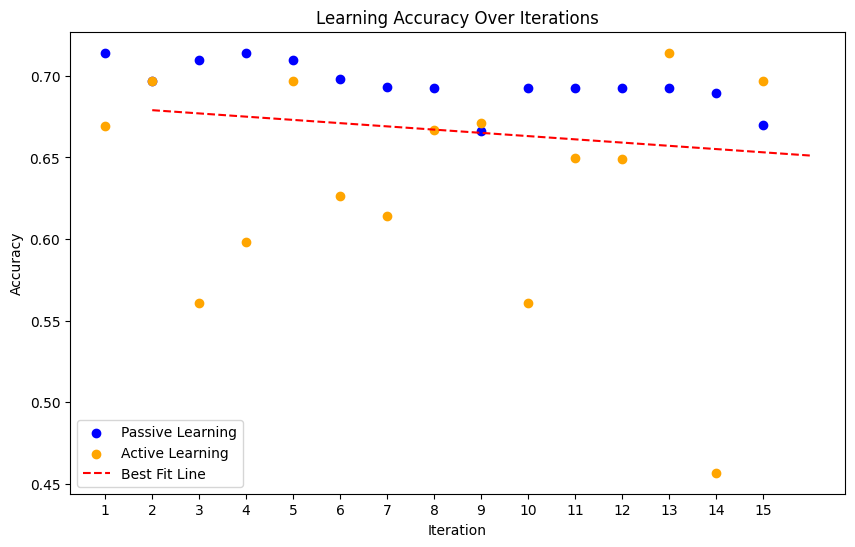

In [16]:
plotAccuracies(v4Results)

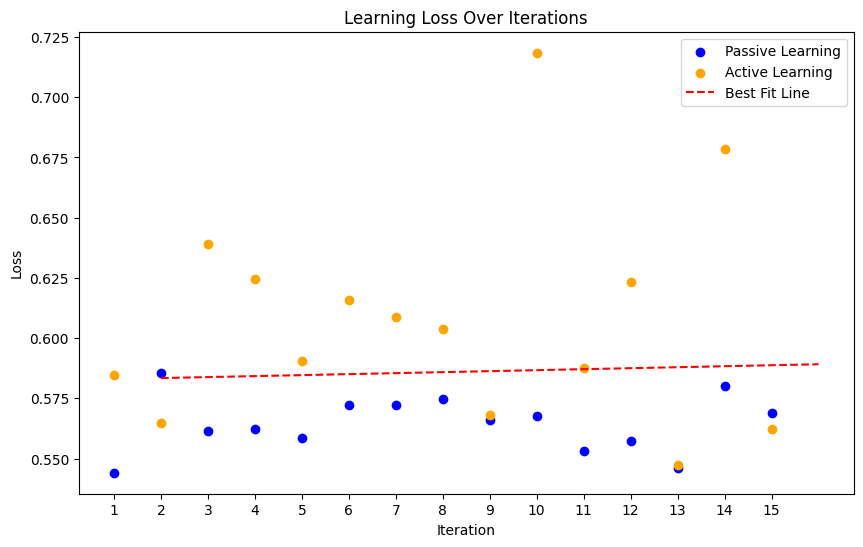

In [17]:
plotLosses(v4Results)